## Load dependencies

In [1]:
# --- standard ---
import os
import sys
import time
from datetime import datetime
from pathlib import Path

# --- scientific ---
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LightSource
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import ndimage
from scipy.interpolate import RBFInterpolator
from scipy.spatial import cKDTree
import scipy.stats as stats

# --- machine learning / preprocessing ---
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- geostatistics ---
import skgstat as skg
from skgstat import models
import gstatsim as gs

# --- image / geometry utilities ---
from skimage.measure import find_contours

# --- parallelization ---
from joblib import Parallel, delayed

# --- local utilities (custom colormap) ---
from utils import geosoft_cmap_k65
geosoft_cmap = geosoft_cmap_k65()
ls = LightSource(azdeg=120, altdeg=45)

# --- local multigrid SGSIM implementation ---
from mgsim import mgsim, mgsim_nst
import sampling
import trendmaking
from variograms import cluster_variogram, build_variogram_dataframe
from synthetic import extract_flightlines


## Load and plot data

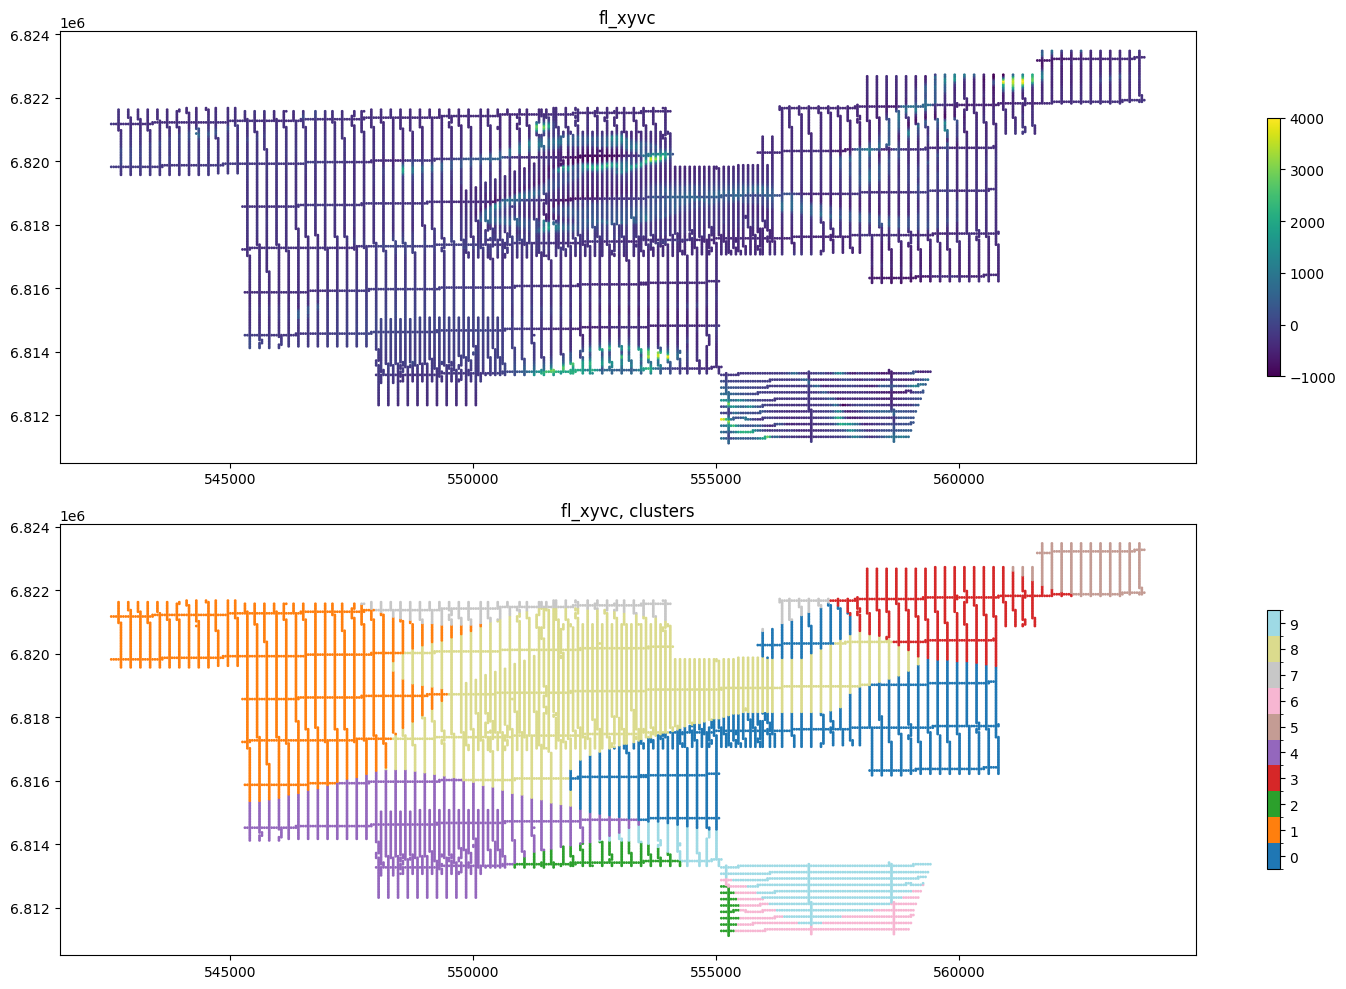

In [2]:
## LOAD AND PLOT CSB INFORMATION FROM .csv FILE ##
## ============================================ ##

# FLIGHT LINES
df_xyvmmc = pd.read_csv('/Users/jrines/stanford_gp/research/mx/computers_geosciences/data/csb_xyvmmc.csv')
df_fl_only = df_xyvmmc[df_xyvmmc["fl_mask"] == 1].drop(columns=["fl_mask", "grid_mask"], errors="ignore")
fl_xyvc = df_fl_only.values

# grid
df_grid_xyvc = df_xyvmmc.drop(columns=["fl_mask", "grid_mask"])

# get number of clusters from gt_xyvc
regions = fl_xyvc[:, 3]
unique_regions = np.unique(regions)
n_regions = len(unique_regions)
# set plot characteristics based on region clustering from gt_xyvc
cmap = plt.colormaps["tab20"].resampled(n_regions)
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(-0.5, n_regions+0.5, 1),
    ncolors=n_regions
)

# plot flight lines and clustering
plt.figure(figsize=(15,10))
plt.subplot(2,1,1)
plt.scatter(fl_xyvc[:,0], fl_xyvc[:,1], c=fl_xyvc[:,2], s=1)
plt.title(f"fl_xyvc")
plt.colorbar(shrink=0.6)
plt.clim(-1000, 4000)

plt.subplot(2,1,2)
plt.title("fl_xyvc, values")
plt.scatter(fl_xyvc[:,0], fl_xyvc[:,1], c=fl_xyvc[:,3], cmap=cmap, norm=norm, s=1)
plt.title(f"fl_xyvc, clusters")
plt.colorbar(shrink=0.6, ticks=np.arange(n_regions))
plt.tight_layout()


## Withhold some flightlines

Holdout: 459 points at x=[549000, 553650, 555250]
Retained: 17104 points


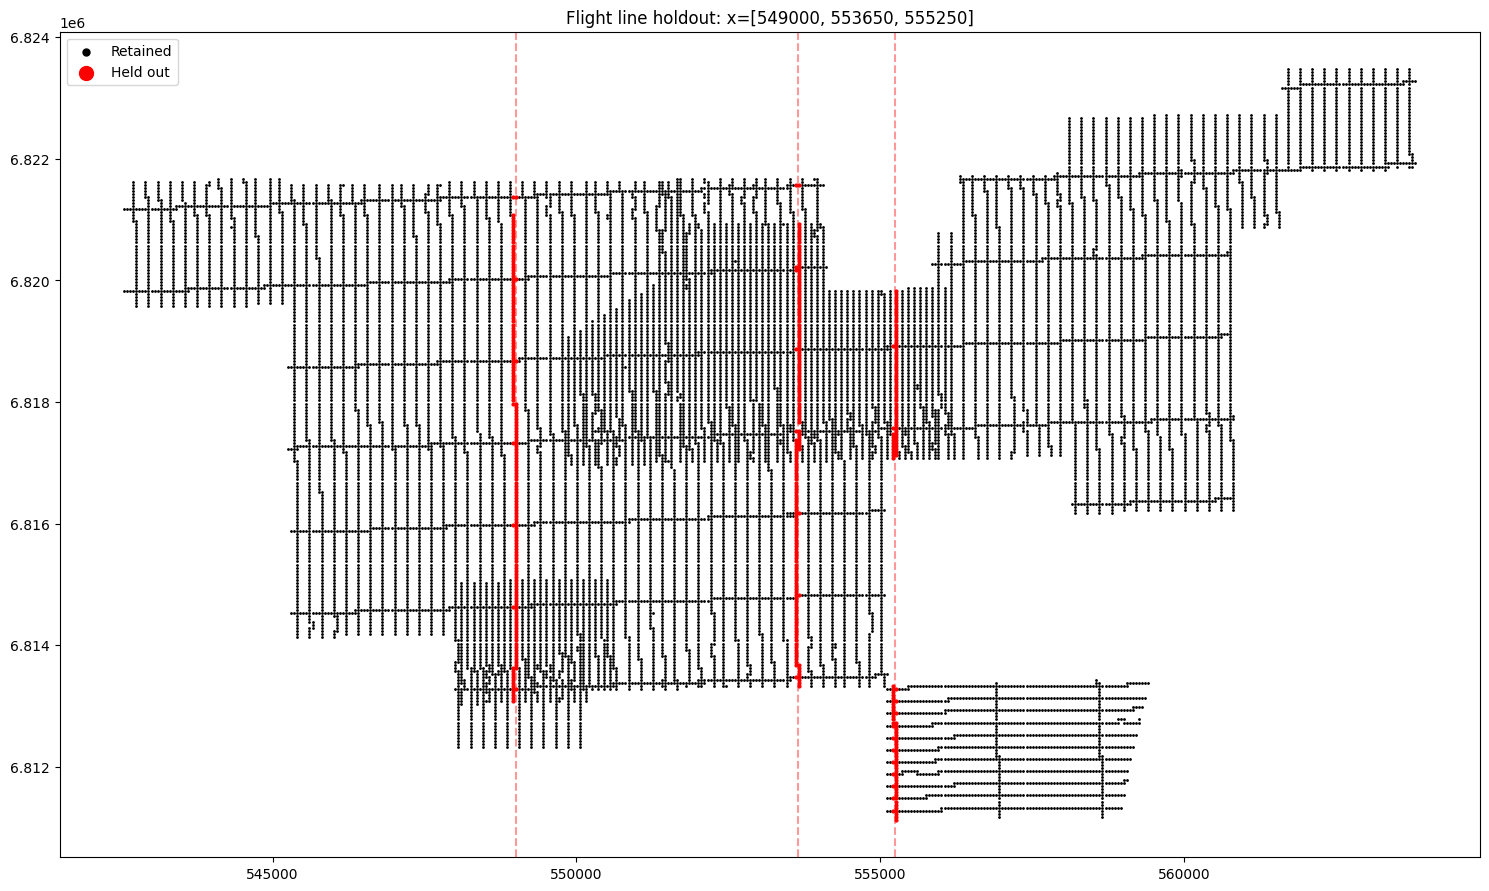

In [22]:
# Pick 3 N-S lines to hold out within x=[550000, 555000]
holdout_x_values = [549000, 553650, 555250]  # adjust as needed
tol = 50

holdout_mask = np.zeros(len(df_fl_only), dtype=bool)
for x_val in holdout_x_values:
    holdout_mask |= (df_fl_only['x'] - x_val).abs() <= tol

df_holdout = df_fl_only[holdout_mask].copy()
df_fl_reduced = df_fl_only[~holdout_mask].copy()

fl_xyvc = df_fl_reduced[['x', 'y', 'val', 'cluster']].values

print(f"Holdout: {len(df_holdout)} points at x={holdout_x_values}")
print(f"Retained: {len(df_fl_reduced)} points")

fig, ax = plt.subplots(figsize=(15, 10))

ax.scatter(df_fl_reduced['x'], df_fl_reduced['y'], s=1, c='black', label='Retained')
ax.scatter(df_holdout['x'], df_holdout['y'], s=4, c='red', label='Held out')

for x_val in holdout_x_values:
    ax.axvline(x_val, color='red', linestyle='--', alpha=0.4)

ax.set_aspect('equal')
ax.set_title(f"Flight line holdout: x={holdout_x_values}")
ax.legend(markerscale=5)
plt.tight_layout()


In [6]:
df_fl_reduced

,x,y,val,cluster
254,555257.731488,6.811125e+06,439.156095,2
680,555257.731488,6.811175e+06,726.979416,2
714,556957.731488,6.811175e+06,-68.267416,6
748,558657.731488,6.811175e+06,654.151002,6
1106,555257.731488,6.811225e+06,569.160897,2
...,...,...,...,...
105629,562907.731488,6.823475e+06,-285.308969,5
105633,563107.731488,6.823475e+06,-432.937705,5
105637,563307.731488,6.823475e+06,-405.156363,5
105641,563507.731488,6.823475e+06,-347.260994,5
